In [1]:
from google.colab import files
uploaded = files.upload()

Saving healthcare_data_cleaning_dataset.csv to healthcare_data_cleaning_dataset.csv


In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('healthcare_data_cleaning_dataset.csv')



Q1. Missing Data Identification

Scenario:
The hospital suspects incomplete patient records.

Task:

- Identify missing values in each column
- Calculate percentage of missing data



Answer:
Missing values and percentage of missing data are calculated below.


In [3]:

missing_values = df.isnull().sum()

missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_report = pd.DataFrame({
    'Missing Values': missing_values,
    'Missing Percentage': missing_percentage
})

missing_report


,Missing Values,Missing Percentage
Patient_ID,0,0.000000
Age,600,11.764706
Gender,0,0.000000
City,0,0.000000
Diagnosis,0,0.000000
Hospital_Visits,0,0.000000
Treatment_Cost,593,11.627451
Insurance_Coverage,0,0.000000
Admission_Date,0,0.000000



Interpretation:
Columns with higher missing percentages require careful handling to maintain data quality.



Q2. Handling Missing Age

Scenario:
Age is critical for medical analysis, but some values are missing.

Task:

- Replace missing Age values with an appropriate method
- Justify your choice (mean/median)



Answer:
Median imputation is used because age data may contain outliers and skewness.


In [4]:

df['Age'] = df['Age'].fillna(df['Age'].median())

print("Missing Age Values After Imputation:")

print(df['Age'].isnull().sum())


Missing Age Values After Imputation:
0



Interpretation:
Median is more robust against extreme age values compared to mean.



Q3. Handling Missing Treatment Cost

Scenario:
Treatment cost is highly skewed due to expensive treatments.

Task:

- Handle missing Treatment_Cost values
- Choose the correct imputation method and explain why



Answer:
Median imputation is used because treatment cost data is highly skewed.


In [5]:

df['Treatment_Cost'] = df['Treatment_Cost'].fillna(
    df['Treatment_Cost'].median()
)

print("Missing Treatment Cost Values After Imputation:")

print(df['Treatment_Cost'].isnull().sum())


Missing Treatment Cost Values After Imputation:
0



Interpretation:
Median reduces the impact of extreme treatment costs during imputation.



Q4. Duplicate Patient Records

Scenario:
Some patient records were entered multiple times.

Task:

- Identify duplicate rows
- Remove duplicates
- Compare dataset size before and after



Answer:
Duplicate rows are identified and removed below.


In [6]:

before_rows = df.shape[0]

duplicate_count = df.duplicated().sum()

df = df.drop_duplicates()

after_rows = df.shape[0]

print("Duplicate Rows:", duplicate_count)

print("Rows Before Removing Duplicates:", before_rows)

print("Rows After Removing Duplicates:", after_rows)


Duplicate Rows: 99
Rows Before Removing Duplicates: 5100
Rows After Removing Duplicates: 5001



Interpretation:
Removing duplicate records improves data accuracy and prevents repeated information.



Q5. Invalid Age Values (Data Quality Check)

Scenario:
Some patients have unrealistic age values (e.g., >100 or <0).

Task:

- Detect such records
- Decide whether to remove or correct them



Answer:
Invalid age values are identified below.


In [7]:

invalid_age_records = df[(df['Age'] < 0) | (df['Age'] > 100)]

invalid_age_records[['Age']]


,Age


In [8]:

df = df[(df['Age'] >= 0) & (df['Age'] <= 100)]

print("Dataset Shape After Removing Invalid Ages:")

print(df.shape)


Dataset Shape After Removing Invalid Ages:
(5001, 9)



Interpretation:
Unrealistic age values are removed because they may negatively affect analysis accuracy.



Q6. Outlier Detection (Treatment Cost)

Scenario:
Extreme treatment costs are affecting analysis.

Task:

- Detect outliers using IQR method
- Display number of outliers



Answer:
Outliers are detected using the IQR method.


In [9]:

Q1 = df['Treatment_Cost'].quantile(0.25)

Q3 = df['Treatment_Cost'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR

upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df['Treatment_Cost'] < lower_bound) |
    (df['Treatment_Cost'] > upper_bound)
]

print("Number of Outliers:", outliers.shape[0])


Number of Outliers: 50



Interpretation:
Extreme treatment cost values are identified as outliers.



Q7. Outlier Treatment

Scenario:
The business team wants to retain all records.

Task:

- Apply capping (Winsorization) on Treatment_Cost
- Use 5th and 95th percentile



Answer:
Treatment costs are capped using 5th and 95th percentile values.


In [10]:

lower_cap = df['Treatment_Cost'].quantile(0.05)

upper_cap = df['Treatment_Cost'].quantile(0.95)

df['Treatment_Cost_Capped'] = np.where(
    df['Treatment_Cost'] < lower_cap,
    lower_cap,
    np.where(
        df['Treatment_Cost'] > upper_cap,
        upper_cap,
        df['Treatment_Cost']
    )
)

df[['Treatment_Cost', 'Treatment_Cost_Capped']].head()


,Treatment_Cost,Treatment_Cost_Capped
0,41010.0,41010.0
1,12194.0,12194.0
2,45086.0,45086.0
3,40842.0,40842.0
4,9873.0,9873.0



Interpretation:
Capping reduces the impact of extreme values while retaining all records.



Q8. Transformation

Scenario:
Treatment cost is highly skewed.

Task:

- Apply log transformation
- Create a new column
- Compare before vs after distribution



Answer:
Log transformation reduces skewness in treatment cost distribution.


In [11]:

df['Log_Treatment_Cost'] = np.log1p(df['Treatment_Cost'])

df[['Treatment_Cost', 'Log_Treatment_Cost']].head()


,Treatment_Cost,Log_Treatment_Cost
0,41010.0,10.621596
1,12194.0,9.408781
2,45086.0,10.716349
3,40842.0,10.617491
4,9873.0,9.197660


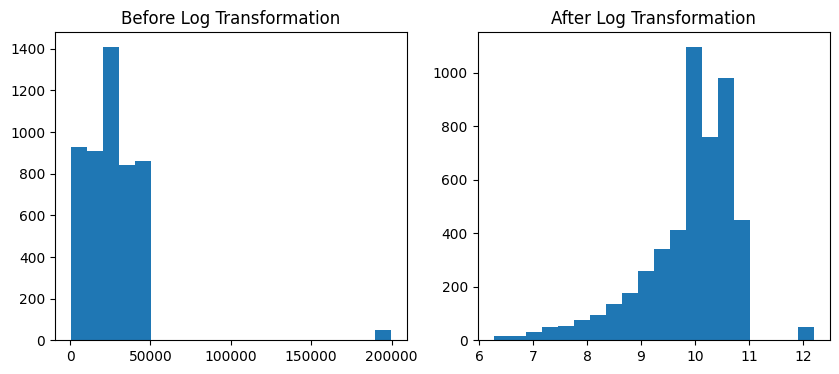

In [12]:

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)

plt.hist(df['Treatment_Cost'], bins=20)

plt.title('Before Log Transformation')

plt.subplot(1,2,2)

plt.hist(df['Log_Treatment_Cost'], bins=20)

plt.title('After Log Transformation')

plt.show()



Interpretation:
Log transformation makes the distribution more balanced and less skewed.



Q9. Time-Based Missing Handling

Scenario:
Admission dates should follow a logical sequence.

Task:

- Sort data by Admission_Date
- Apply forward fill or backward fill where appropriate
- Justify your choice



Answer:
Forward fill is applied after sorting by admission date.


In [13]:

df['Admission_Date'] = pd.to_datetime(df['Admission_Date'])

df = df.sort_values('Admission_Date')

df = df.fillna(method='ffill')

df.head()


/tmp/ipykernel_30661/4056348560.py:5: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')


,Patient_ID,Age,Gender,City,Diagnosis,Hospital_Visits,Treatment_Cost,Insurance_Coverage,Admission_Date,Treatment_Cost_Capped,Log_Treatment_Cost
2932,19591,91.0,Male,Chennai,Asthma,3,32149.000000,0,2023-01-01,32149.0,10.378168
4617,10896,88.0,Female,Chennai,COVID-19,3,199702.965333,1,2023-01-01,47948.0,12.204591
2642,19262,50.0,Female,Hyderabad,Asthma,9,24797.000000,0,2023-01-01,24797.0,10.118518
4837,12843,89.0,Female,Bangalore,COVID-19,14,46469.000000,1,2023-01-01,46469.0,10.746562
2702,17230,41.0,Male,Bangalore,Hypertension,18,12398.000000,0,2023-01-01,12398.0,9.425371



Interpretation:
Forward fill maintains logical continuity in time-based healthcare records.
